# GAMBIT — CDEA Pipeline Tutorial

**GAMBIT** (Game-theoretic Allocation for Model-Based Interpretability and Trust) implements the
**CDEA** (Contrastive Decomposition via Evidence Allocation) pipeline: a unified, game-theoretic
framework for producing contrastive, interpretable model explanations.

This notebook walks through the full pipeline:

1. Load a model and a batch of images
2. Run the **Contrastive Explainer** — *"Why did the model predict class K rather than class L?"*
3. Visualise evidence heatmaps, unique/shared masks, probability splits, and pairwise margins
4. Compare **evidence providers** (Grad-CAM vs Integrated Gradients)
5. Compare **game modes** (cooperative / mixed / competitive)
6. Run the **Shift Explainer** — separate robust from shortcut evidence under distribution shift

---
> **Prerequisites:** install the package once from the repo root:
> ```bash
> pip install -e /path/to/gambit
> ```

In [232]:
# Uncomment to install if not already done
# import subprocess, sys
# subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', '../..'], check=True)

In [233]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

import gambit
from gambit import EnvBatch
from core.visualization import (
    mask_to_image,
    extract_layer_activations,
    show_evidence_heatmap,
    show_explanation_gallery,
    show_gradcam_vs_ig,
    show_probability_split,
    show_pairwise_margin,
    show_evidence_region_bars,
    show_feature_activations,
)

REPO = Path('../..')
OUT  = REPO / 'examples' / 'out'
OUT.mkdir(parents=True, exist_ok=True)

print('torch:', torch.__version__)
print('device:', 'cuda' if torch.cuda.is_available() else 'cpu')

torch: 2.9.1
device: cpu


## 1. Configuration

Change `DATASET` and `CHECKPOINT` to use your own data.  
All parameters are documented in `gambit.ContrastiveExplainer`.

In [234]:
DATASET    = 'pets'      # mnist | cifar10 | pets | stanford_dogs
MODEL_NAME = 'resnet18'
BATCH_SIZE = 2
TOP_K      = 2           # number of top classes to explain per image (capped to num_classes below)
GAME_MODE  = 'mixed'     # cooperative | mixed | competitive
NUM_STEPS  = 30          # allocator optimisation steps (increase for sharper masks)
IMG_SIZE   = 224         # input resolution expected by the model
GRID_SIZE  = 7           # spatial grid: 7 for CNNs, 14 for ViT

# Auto-resolve to the best available checkpoint for the chosen dataset.
# Override with an explicit path string to use your own checkpoint.
CKPT_DIR = REPO / 'scripts' / 'out' / 'checkpoints'
_CKPT_MAP = {
    'cifar10':       CKPT_DIR / 'cifar10_resnet18_pt_lp_ep15.pt',
    'mnist':         CKPT_DIR / 'mnist_resnet18_pt_lp_ep15.pt',
    'pets':          CKPT_DIR / 'pets_resnet18_pt_lp_ep15.pt',
    'stanford_dogs': CKPT_DIR / 'stanford_dogs_resnet18_pt_lp_ep15.pt',
}
CHECKPOINT = _CKPT_MAP.get(DATASET)  # set to None to use ImageNet pretrained only

NUM_CLASSES = {
    'mnist': 10, 'cifar10': 10, 'pets': 2, 'stanford_dogs': 120
}[DATASET]

# Cap TOP_K to the number of classes — no point in duplicate hypotheses
TOP_K = min(TOP_K, NUM_CLASSES)

## 2. Load Model

In [235]:
from torchvision import models

CLASS_NAMES = {
    'mnist':         [str(i) for i in range(10)],
    'cifar10':       ['airplane','automobile','bird','cat','deer',
                      'dog','frog','horse','ship','truck'],
    'pets':          ['Cat', 'Dog'],
    'stanford_dogs': None,   # populated below when dataset is loaded
}[DATASET]

model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

if CHECKPOINT and Path(CHECKPOINT).exists():
    state = torch.load(CHECKPOINT, map_location='cpu', weights_only=True)
    # Unwrap if saved as {'state_dict': ..., 'dataset': ..., ...}
    if isinstance(state, dict) and 'state_dict' in state:
        state = state['state_dict']
    model.load_state_dict(state)
    print(f'Loaded checkpoint: {Path(CHECKPOINT).name}')
elif CHECKPOINT:
    print(f'Checkpoint not found at {CHECKPOINT}, falling back to ImageNet pretrained.')
else:
    print('No checkpoint specified — using ImageNet pretrained backbone.')
    print('For meaningful explanations on your dataset, set CHECKPOINT above.')

model.eval()
print(f'Model: {MODEL_NAME}, output classes: {NUM_CLASSES}, TOP_K: {TOP_K}')

Loaded checkpoint: pets_resnet18_pt_lp_ep15.pt
Model: resnet18, output classes: 2, TOP_K: 2


## 3. Load a Batch of Images

In [236]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

DATA_ROOT = REPO / 'data'
resize    = transforms.Resize((IMG_SIZE, IMG_SIZE))
to_tensor = transforms.ToTensor()

def _try_load_dataset():
    if DATASET == 'mnist':
        t = transforms.Compose([to_tensor,
                                 transforms.Lambda(lambda t: t.repeat(3,1,1)),
                                 resize])
        return datasets.MNIST(DATA_ROOT, train=False, download=False, transform=t)
    elif DATASET == 'cifar10':
        t = transforms.Compose([to_tensor, resize])
        return datasets.CIFAR10(DATA_ROOT, train=False, download=False, transform=t)
    elif DATASET == 'pets':
        t = transforms.Compose([resize, to_tensor])
        return datasets.ImageFolder(DATA_ROOT / 'PetImages', transform=t)
    elif DATASET == 'stanford_dogs':
        t = transforms.Compose([resize, to_tensor])
        return datasets.ImageFolder(DATA_ROOT / 'stanford_dogs' / 'images' / 'Images', transform=t)

try:
    ds = _try_load_dataset()
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    x_batch, y_batch = next(iter(loader))
    if DATASET == 'stanford_dogs' and CLASS_NAMES is None:
        CLASS_NAMES = [c.split('-',1)[1].replace('_',' ') if '-' in c else c
                       for c in ds.classes]
    print(f'Loaded {DATASET}: batch shape {x_batch.shape}')
except Exception as e:
    print(f'Dataset not found ({e}). Using random tensors as fallback.')
    x_batch = torch.rand(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE)
    y_batch = torch.zeros(BATCH_SIZE, dtype=torch.long)

x = x_batch  # (B, 3, H, W)

Loaded pets: batch shape torch.Size([2, 3, 224, 224])


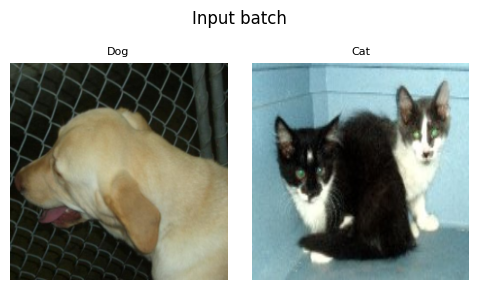

In [237]:
# Quick sanity check: show the batch
fig, axes = plt.subplots(1, BATCH_SIZE, figsize=(2.5 * BATCH_SIZE, 2.8))
for i, ax in enumerate(axes):
    img = x[i].permute(1, 2, 0).cpu().numpy().clip(0, 1)
    ax.imshow(img)
    label = CLASS_NAMES[int(y_batch[i])] if CLASS_NAMES else str(int(y_batch[i]))
    ax.set_title(label, fontsize=8)
    ax.axis('off')
plt.suptitle('Input batch', y=1.02)
plt.tight_layout()
plt.show()

## 4. Create the Contrastive Explainer

The `ContrastiveExplainer` wires up:
- **HypothesisSelector** — picks the top-K predicted classes
- **BaseEvidenceProvider** — computes Grad-CAM (or IG) evidence per spatial region per class
- **Allocator** — optimises unique masks for each class under the game-theoretic objective
- **Objective** — balances sufficiency, contrastive margin, overlap, and sparsity penalties

All of this is hidden behind a single constructor call.

In [238]:
explainer = gambit.ContrastiveExplainer(
    model,
    game_mode  = GAME_MODE,
    evidence   = 'gradcam',
    grid_size  = GRID_SIZE,
    top_k      = TOP_K,
    num_steps  = NUM_STEPS,
)
print(explainer)

## 5. Run the Explanation

`explain(x)` returns an `Explanation` object with:
- **`.hypotheses`** — top-K class indices and the soft selection mask
- **`.masks`** — `unique` (B, K, R) and `shared` (B, R) region masks
- **`.metrics`** — sufficiency, margin, overlap, sparsity, probability splits
- **`.extras`** — raw probabilities, evidence, attention weights

In [239]:
explanation = explainer.explain(x)

print('Batch size:       ', x.shape[0])
print('Top-K classes:    ', explanation.hypotheses.ids.shape)   # (B, K)
print('Unique masks:     ', explanation.masks['unique'].shape)   # (B, K, R)
print('Shared mask:      ', explanation.masks['shared'].shape)   # (B, R)
print('\nKey metrics (batch mean):')
for key in ('suff', 'margin', 'overlap', 'sparse'):
    val = explanation.metrics[key]
    if isinstance(val, torch.Tensor):
        val = val.mean()
    print(f'  {key:8s}: {float(val):.4f}')

Batch size:        2
Top-K classes:     torch.Size([2, 2])
Unique masks:      torch.Size([2, 2, 49])
Shared mask:       torch.Size([2, 49])

Key metrics (batch mean):
  suff    : 2.2488
  margin  : 3.6204
  overlap : 0.0013
  sparse  : 5.9048


In [240]:
# Which classes was the model asked to explain for each image?
probs = explanation.extras['probs'].detach()  # (B, num_classes)

print(f'{'Image':>6}  {'Predicted':>20}  {'Top-K hypotheses'}')
print('-' * 60)
for i in range(x.shape[0]):
    pred = int(probs[i].argmax())
    pred_name = CLASS_NAMES[pred] if CLASS_NAMES else str(pred)
    hyp_ids   = explanation.hypotheses.ids[i].tolist()
    hyp_names = [CLASS_NAMES[h] if CLASS_NAMES else str(h) for h in hyp_ids]
    print(f'  [{i}]   {pred_name:>20}  {hyp_names}')

 Image             Predicted  Top-K hypotheses
------------------------------------------------------------
  [0]                    Dog  ['Dog', 'Cat']
  [1]                    Cat  ['Cat', 'Dog']


## 6. Evidence Heatmaps

Raw Grad-CAM evidence (before allocation) overlaid on the input image.  
This shows *where* the model looks for each class hypothesis, before the game-theoretic
optimisation carves out unique vs shared regions.

In [241]:
evidence = explanation.extras['evidence']  # (B, K, R)

fig = show_evidence_heatmap(
    x,
    evidence,
    explanation.hypotheses.ids,
    explainer.unit_space,
    class_names = CLASS_NAMES,
    sample_idx  = 0,
    title       = f'Grad-CAM Evidence — sample 0',
)
fig.show()

## 7. Explanation Gallery

For each image the gallery shows:
- **Input** — original image with true label and predicted label burned in
- **Evidence** — Grad-CAM heatmap per class (hot colormap)
- **Allocation** — allocated masks per class (colorblind-safe):
  - 🔵 **Blue** = unique evidence (class-specific)
  - 🟠 **Orange** = shared evidence (common across all hypotheses)
  - 🟣 **Purple** = both

The allocation is the key CDEA output: it answers  
> *"Which regions are uniquely responsible for class K, and which are shared across all hypotheses?"*

In [242]:
fig = show_explanation_gallery(
    x,
    explanation,
    explainer.unit_space,
    class_names  = CLASS_NAMES,
    probs        = probs,
    true_labels  = y_batch,
    max_classes  = TOP_K,
    title        = f'CDEA Gallery — {DATASET}, game_mode={GAME_MODE}',
    out_path     = OUT / f'tutorial_gallery_{DATASET}.html',
)
fig.show()

## 8. Probability Split

The allocator evaluates the model *twice* per class:
1. **Shared-only** — keep only the regions in the shared mask → baseline probability
2. **Shared + Unique** — add the class-specific unique mask → full probability

The **delta** (right panel) is the unique contribution of each class's private evidence.
A large delta means the unique mask carries real discriminative information.

In [243]:
fig = show_probability_split(
    explanation,
    class_names = CLASS_NAMES,
    sample_idx  = 0,
    title       = 'Probability Split — shared-only vs shared+unique',
    out_path    = OUT / f'tutorial_prob_split_{DATASET}.html',
)
if fig:
    fig.show()
else:
    print('Probability split metrics not available (requires mixed/cooperative game mode).')

## 9. Pairwise Contrastive Margin

Each cell (k, l) answers:  
> *"When I keep the evidence for class k, how much higher is logit(k) than logit(l)?"*

- 🟢 **Positive** (green) — the mask for class k successfully discriminates against class l
- 🔴 **Negative** (red)   — the mask fails to separate the two (weak explanation)

The right panel shows the **delta** — how much the unique evidence improves on shared-only.

In [244]:
fig = show_pairwise_margin(
    explanation,
    class_names = CLASS_NAMES,
    sample_idx  = 0,
    title       = 'Pairwise Contrastive Margin',
    out_path    = OUT / f'tutorial_pairwise_{DATASET}.html',
)
if fig:
    fig.show()
else:
    print('Pairwise margin metrics not available.')

## 10. Evidence Distribution per Region

The spatial heatmap blurs over grid boundaries.  
This bar chart shows the **exact evidence mass per region per class**,
making it easy to spot regions where multiple classes compete.

In [245]:
fig = show_evidence_region_bars(
    evidence,
    explanation.hypotheses.ids,
    class_names = CLASS_NAMES,
    sample_idx  = 0,
    grid_h      = explainer.unit_space.grid_h,
    grid_w      = explainer.unit_space.grid_w,
    title       = 'Evidence Distribution per Grid Region',
    out_path    = OUT / f'tutorial_region_bars_{DATASET}.html',
)
fig.show()

## 11. Feature Activations

Look *inside* the backbone: these are the raw channel activations at the GradCAM target layer
(last Conv2d for ResNet), before gradient weighting.  
They show what the network has learned to detect.

In [246]:
device = next(model.parameters()).device
activations = extract_layer_activations(model, x.to(device))
print('Activation tensor shape:', activations.shape)  # (B, C, h, w)

fig = show_feature_activations(
    x,
    activations,
    explainer.unit_space,
    sample_idx = 0,
    n_channels = 6,
    title      = f'Top-6 Feature Channels — {MODEL_NAME}',
    out_path   = OUT / f'tutorial_features_{DATASET}_{MODEL_NAME}.html',
)
fig.show()

Activation tensor shape: torch.Size([2, 512, 7, 7])


## 12. Compare Evidence Providers: Grad-CAM vs Integrated Gradients

CDEA is agnostic to the evidence provider.  
Here we run both **Grad-CAM** and **Integrated Gradients (IG)** and compare the evidence they produce.
IG is gradient-path based and can capture finer attribution; Grad-CAM is faster and more spatially smooth.

> Note: IG is slower — reduce `ig_steps` for a quicker run.

In [253]:
IG_STEPS = 16  # reduce for speed; 24–50 for production quality

explainer_ig = gambit.ContrastiveExplainer(
    model,
    game_mode = GAME_MODE,
    evidence  = 'ig',
    grid_size = GRID_SIZE,
    top_k     = TOP_K,
    num_steps = NUM_STEPS,
    ig_steps  = IG_STEPS,
)

explanation_ig = explainer_ig.explain(x)
print('IG explanation done.')

fig = show_gradcam_vs_ig(
    x,
    explanations   = {'Grad-CAM': explanation, 'Integ. Grad.': explanation_ig},
    unit_space     = explainer.unit_space,
    class_names    = CLASS_NAMES,
    sample_idx     = 1,
    max_classes    = TOP_K,
    title          = 'Evidence Provider Comparison: Grad-CAM vs Integrated Gradients',
    out_path       = OUT / f'tutorial_gradcam_vs_ig_{DATASET}.html',
)
fig.show()

IG explanation done.


## 13. Compare Game Modes

The **game mode** controls the penalty structure in the allocation objective:

| Mode | Shared mask | Margin penalty | Overlap penalty | Effect |
|------|:-----------:|:--------------:|:---------------:|--------|
| `cooperative` | ✔ | off | off | Emphasises shared evidence; minimal competition |
| `mixed` | ✔ | moderate | moderate | Balanced unique + shared decomposition |
| `competitive` | ✗ | strong | strong | Maximally disjoint unique masks per class |

Below we run all three and compare the resulting metrics.

In [248]:
mode_results = {}
for mode in ('cooperative', 'mixed', 'competitive'):
    exp_m = gambit.ContrastiveExplainer(
        model, game_mode=mode, evidence='gradcam',
        grid_size=GRID_SIZE, top_k=TOP_K, num_steps=NUM_STEPS,
    ).explain(x)
    mode_results[mode] = exp_m
    suff   = float(exp_m.metrics['suff'].mean())
    margin = float(exp_m.metrics['margin'].mean())
    ovlp   = float(exp_m.metrics['overlap'].mean())
    print(f'{mode:>14}  suff={suff:.3f}  margin={margin:.3f}  overlap={ovlp:.3f}')

   cooperative  suff=1.715  margin=2.115  overlap=0.000
         mixed  suff=2.249  margin=3.620  overlap=0.001
   competitive  suff=1.275  margin=1.401  overlap=0.002


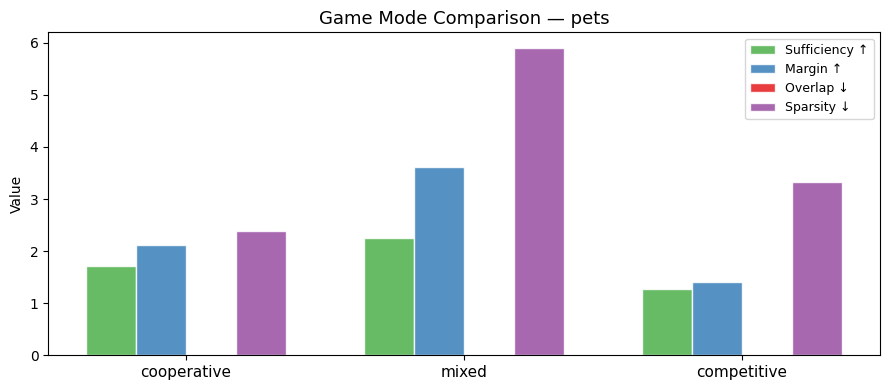

In [249]:
modes   = ['cooperative', 'mixed', 'competitive']
metrics = ['suff', 'margin', 'overlap', 'sparse']
labels  = ['Sufficiency ↑', 'Margin ↑', 'Overlap ↓', 'Sparsity ↓']
colors  = ['#4daf4a', '#377eb8', '#e41a1c', '#984ea3']

data = {
    m: [float(mode_results[mode].metrics[m].mean()) for mode in modes]
    for m in metrics
}

x_pos = np.arange(len(modes))
bar_w = 0.18

fig, ax = plt.subplots(figsize=(9, 4))
for i, (metric, label, color) in enumerate(zip(metrics, labels, colors)):
    offset = (i - len(metrics)/2 + 0.5) * bar_w
    ax.bar(x_pos + offset, data[metric], bar_w,
           label=label, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x_pos)
ax.set_xticklabels(modes, fontsize=11)
ax.set_ylabel('Value')
ax.set_title(f'Game Mode Comparison — {DATASET}', fontsize=13)
ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(OUT / f'tutorial_mode_comparison_{DATASET}.png', dpi=120)
plt.show()

## 14. Shift-Aware Explanation (Robust vs Shortcut)

The `ShiftExplainer` answers a different question:  
> *"Which evidence is **robust** (stable across environments) vs a **shortcut** (ID-specific artefact)?"*

It requires an `EnvBatch` — a collection of views from different environments (e.g. in-distribution
vs out-of-distribution).  Here we simulate two environments by applying mild augmentations.

In a real experiment you would supply actual OOD data (see `scripts/eval_robust_shortcut.py`).

In [250]:
# Simulate two environments: original (ID) and colour-jittered (OOD)
x_id  = x
x_ood = transforms.functional.adjust_saturation(x, saturation_factor=0.0)  # grayscale

env = EnvBatch(xs=[x_id, x_ood], env_ids=[0, 1])
print('ID batch: ', x_id.shape)
print('OOD batch:', x_ood.shape)

ID batch:  torch.Size([2, 3, 224, 224])
OOD batch: torch.Size([2, 3, 224, 224])


In [251]:
shift_explainer = gambit.ShiftExplainer(
    model,
    game_mode = 'mixed',
    evidence  = 'gradcam',
    grid_size = GRID_SIZE,
    top_k     = TOP_K,
    num_steps = NUM_STEPS,
)

shift_exp = shift_explainer.explain(x, env=env)

print('Robust mask: ', shift_exp.masks['robust'].shape)    # (B, R)
print('Shortcut mask:', shift_exp.masks['shortcut'].shape) # (B, R)
print('\nShift metrics (batch mean):')
for key in ('rob_mean', 'rob_var', 'sho_gap', 'disjoint', 'sparse'):
    if key in shift_exp.metrics:
        val = shift_exp.metrics[key]
        if isinstance(val, torch.Tensor):
            val = val.mean()
        print(f'  {key:12s}: {float(val):.4f}')

Robust mask:  torch.Size([2, 49])
Shortcut mask: torch.Size([2, 49])

Shift metrics (batch mean):
  rob_mean    : 1.6248
  rob_var     : 0.0004
  sho_gap     : 0.3057
  disjoint    : 0.6701
  sparse      : 7.2469


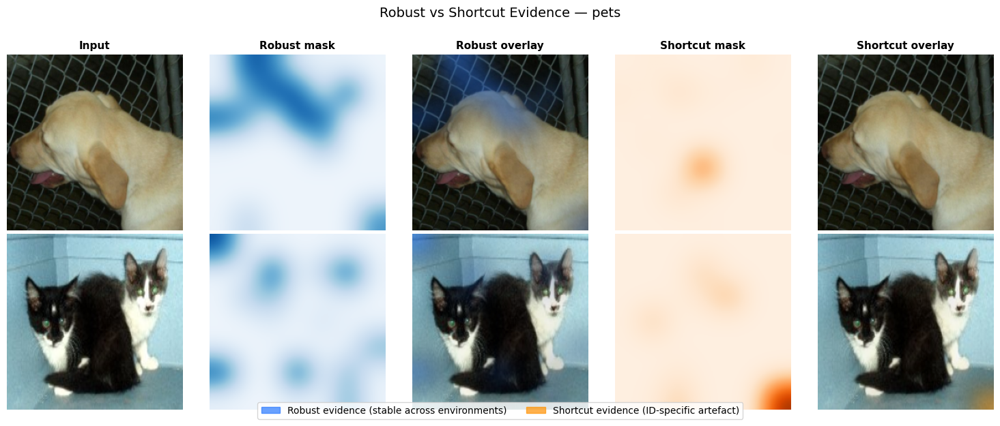

In [252]:
# Visualise robust vs shortcut masks for each sample in the batch
B = x.shape[0]
gh, gw = shift_explainer.unit_space.grid_h, shift_explainer.unit_space.grid_w
H, W   = x.shape[2], x.shape[3]

from matplotlib.colors import LinearSegmentedColormap
cmap_robust   = LinearSegmentedColormap.from_list('robust',   ['#00000000', '#2979FF'])
cmap_shortcut = LinearSegmentedColormap.from_list('shortcut', ['#00000000', '#FF9100'])

# Layout: each row = one sample, cols = [Input, Robust mask, Robust overlay, Shortcut mask, Shortcut overlay]
n_cols = 5
col_labels = ['Input', 'Robust mask', 'Robust overlay', 'Shortcut mask', 'Shortcut overlay']

fig, axes = plt.subplots(B, n_cols, figsize=(3 * n_cols, 3 * B))
if B == 1:
    axes = axes[np.newaxis, :]  # ensure 2D

for i in range(B):
    img = x[i].permute(1, 2, 0).cpu().numpy().clip(0, 1)

    rob_mask = mask_to_image(
        shift_exp.masks['robust'][i].detach().cpu(), gh, gw, H, W
    )
    sho_mask = mask_to_image(
        shift_exp.masks['shortcut'][i].detach().cpu(), gh, gw, H, W
    )

    # Col 0: Input
    axes[i, 0].imshow(img)

    # Col 1: Robust mask only (no image underneath)
    axes[i, 1].imshow(rob_mask, cmap='Blues', vmin=0, vmax=1)

    # Col 2: Robust overlay on image
    axes[i, 2].imshow(img)
    axes[i, 2].imshow(rob_mask, cmap=cmap_robust, alpha=0.7, vmin=0, vmax=1)

    # Col 3: Shortcut mask only (no image underneath)
    axes[i, 3].imshow(sho_mask, cmap='Oranges', vmin=0, vmax=1)

    # Col 4: Shortcut overlay on image
    axes[i, 4].imshow(img)
    axes[i, 4].imshow(sho_mask, cmap=cmap_shortcut, alpha=0.7, vmin=0, vmax=1)

    for j in range(n_cols):
        axes[i, j].axis('off')

# Column titles on top row only
for j, label in enumerate(col_labels):
    axes[0, j].set_title(label, fontsize=11, fontweight='bold', pad=6)

blue_patch   = mpatches.Patch(color='#2979FF', alpha=0.7, label='Robust evidence (stable across environments)')
orange_patch = mpatches.Patch(color='#FF9100', alpha=0.7, label='Shortcut evidence (ID-specific artefact)')
fig.legend(handles=[blue_patch, orange_patch], loc='lower center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.01))

plt.suptitle(f'Robust vs Shortcut Evidence — {DATASET}', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUT / f'tutorial_shift_{DATASET}.png', dpi=120, bbox_inches='tight')
plt.show()

## Summary

| Step | API call | Output |
|------|----------|--------|
| Create explainer | `gambit.ContrastiveExplainer(model, ...)` | Configured pipeline |
| Run explanation | `explainer.explain(x)` | `Explanation` object |
| Evidence heatmaps | `show_evidence_heatmap(...)` | Where the model looks per class |
| Gallery | `show_explanation_gallery(...)` | Unique / shared mask overlays |
| Probability split | `show_probability_split(...)` | Unique mask contribution |
| Pairwise margin | `show_pairwise_margin(...)` | Class discrimination strength |
| Region bars | `show_evidence_region_bars(...)` | Per-cell evidence breakdown |
| Feature channels | `show_feature_activations(...)` | Backbone internal features |
| Provider comparison | `show_gradcam_vs_ig(...)` | Grad-CAM vs IG evidence |
| Game mode comparison | run all three + bar chart | Cooperative/Mixed/Competitive |
| Shift explanation | `gambit.ShiftExplainer(model, ...).explain(x, env)` | Robust vs shortcut masks |

---
**Next steps:**
- Fine-tune a backbone on your dataset and pass the checkpoint path as `CHECKPOINT`
- Swap in real OOD data for the shift explainer
- Run `scripts/run_experiments.py` to reproduce the full ablation study
- See `docs/NEW_INSTANTIATION_GAME_GUIDE.md` to add a custom game instantiation